In [22]:
"""
Attention-BBox Alignment Metrics for ResNet-50 Comparison
Supports both GradCAM (baseline) and Spatial Attention (enhanced)
"""

import torch
import torch.nn.functional as F
import numpy as np
import cv2
from sklearn.metrics import auc
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import timm
import cv2

In [23]:
# Paths
split_base_path = "./dataset_nodule21/cxr_images/proccessed_data/split_data"
checkpoint_path = "./resnet50_binary.pth"

train_images_path = f"{split_base_path}/train/images"
val_images_path = f"{split_base_path}/val/images"
test_images_path = f"{split_base_path}/test/images"

train_csv_path = f"{split_base_path}/train/metadata_no_aug.csv"
val_csv_path = f"{split_base_path}/val/metadata_val.csv"
test_csv_path = f"{split_base_path}/test/metadata_test.csv"

# ============================================================================
# LOAD DATA
# ============================================================================

print("\nLoading datasets...")
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets with bbox
from NoduleDS import NoduleDataset

train_dataset = NoduleDataset(train_df, train_images_path, transform=train_transform, return_bbox=True)
val_dataset = NoduleDataset(val_df, val_images_path, transform=val_transform, return_bbox=True)
test_dataset = NoduleDataset(test_df, test_images_path, transform=val_transform, return_bbox=True)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)



Loading datasets...
Train samples: 3657
Val samples: 782
Test samples: 785


In [24]:
# ============================================================================
# Spatial Attention Module
# ============================================================================

class SpatialAttentionModule(nn.Module):
    """
    Learnable spatial attention module
    Takes features from backbone and outputs spatial attention weights
    """
    def __init__(self, in_channels=2048, reduction=8):
        super(SpatialAttentionModule, self).__init__()
        
        # Spatial attention pathway
        self.conv1 = nn.Conv2d(in_channels, in_channels // reduction, kernel_size=1)
        self.bn1 = nn.BatchNorm2d(in_channels // reduction)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(in_channels // reduction, in_channels // reduction, 
                               kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(in_channels // reduction)
        
        # Output attention map
        self.conv_out = nn.Conv2d(in_channels // reduction, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        """
        Args:
            x: [B, 2048, 7, 7] features from backbone
        Returns:
            attention: [B, 1, 7, 7] spatial attention map
            weighted_features: [B, 2048, 7, 7] attention-weighted features
        """
        # Generate spatial attention
        att = self.conv1(x)
        att = self.bn1(att)
        att = self.relu(att)
        
        att = self.conv2(att)
        att = self.bn2(att)
        att = self.relu(att)
        
        att = self.conv_out(att)
        attention = self.sigmoid(att)  # [B, 1, 7, 7]
        
        # Apply attention to features
        weighted_features = x * attention
        
        return attention, weighted_features

In [25]:
# ============================================================================
# WSOD Model with Spatial Attention
# ============================================================================

class WSODModelWithAttention(nn.Module):
    def __init__(self, base_model, num_classes=2, freeze_backbone=True):
        super(WSODModelWithAttention, self).__init__()
        
        # Freeze backbone if requested
        if freeze_backbone:
            for param in base_model.parameters():
                param.requires_grad = False
            print("✓ Backbone frozen")
        
        # Extract feature extractor (everything except FC)
        self.features = nn.Sequential(*list(base_model.children())[:-2])  # Up to layer4
        self.avgpool = list(base_model.children())[-2]  # AdaptiveAvgPool2d
        
        # Add spatial attention module (TRAINABLE)
        self.spatial_attention = SpatialAttentionModule(in_channels=2048)
        
        # Classifier head (TRAINABLE)
        self.fc = nn.Linear(2048, num_classes)
        
        # If backbone is frozen, unfreeze only the FC from base_model
        if freeze_backbone:
            # Copy weights from original FC if available
            original_fc = list(base_model.children())[-1]
            if isinstance(original_fc, nn.Linear):
                self.fc.weight.data.copy_(original_fc.weight.data)
                self.fc.bias.data.copy_(original_fc.bias.data)
        
    def forward(self, x, return_attention=False):
        # Extract features from frozen backbone
        features = self.features(x)  # [B, 2048, 7, 7]
        
        # Apply spatial attention
        attention_map, weighted_features = self.spatial_attention(features)
        
        # Global average pooling
        pooled = self.avgpool(weighted_features)  # [B, 2048, 1, 1]
        pooled = pooled.flatten(1)  # [B, 2048]
        
        # Classification
        output = self.fc(pooled)
        
        if return_attention:
            return output, attention_map
        return output
    
    def get_attention_map(self, x):
        """Get spatial attention map for visualization"""
        with torch.no_grad():
            features = self.features(x)
            attention_map, _ = self.spatial_attention(features)
        return attention_map

In [26]:
# ============================================================================
# GRADCAM IMPLEMENTATION (for baseline model)
# ============================================================================

# ============================================================================
# GRADCAM IMPLEMENTATION (for baseline model)
# ============================================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_image, class_idx=None):
        """Generate GradCAM heatmap"""
        # Forward pass
        model_output = self.model(input_image)
        
        if class_idx is None:
            class_idx = model_output.argmax(dim=1).item()
        
        # Backward pass
        self.model.zero_grad()
        class_score = model_output[0, class_idx]
        class_score.backward()
        
        # Generate CAM
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        for i in range(self.activations.shape[1]):
            self.activations[:, i, :, :] *= pooled_gradients[i]
        
        heatmap = torch.mean(self.activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= (torch.max(heatmap) + 1e-8)
        
        return heatmap.cpu().numpy()

In [27]:
class AttentionBBoxMetrics:
    """
    Metrics for evaluating if bounding boxes fall within attention regions
    (Assistive technology approach: attention should cover bbox area)
    """
    
    def __init__(self, model, device, use_gradcam=False, target_size=224):
        self.model = model
        self.device = device
        self.use_gradcam = use_gradcam
        self.target_size = target_size
        
        # Initialize GradCAM if needed
        if use_gradcam:
            target_layer = model.layer4[-1]
            self.gradcam = GradCAM(model, target_layer)
            print(f"  Using GradCAM for attention visualization")
        else:
            self.gradcam = None
            print(f"  Using Spatial Attention for visualization")
    
    def compute_bbox_mask(self, bbox, size=224):
        """Create binary mask from normalized bbox coordinates"""
        mask = np.zeros((size, size), dtype=np.float32)
        
        x, y, w, h = bbox.cpu().numpy()
        x_pix = int(x * size)
        y_pix = int(y * size)
        w_pix = int(w * size)
        h_pix = int(h * size)
        
        # Clamp to valid range
        x_end = min(x_pix + w_pix, size)
        y_end = min(y_pix + h_pix, size)
        x_pix = max(0, x_pix)
        y_pix = max(0, y_pix)
        
        mask[y_pix:y_end, x_pix:x_end] = 1.0
        return mask
    
    def get_attention_map(self, image):
        """Extract and resize attention map from model"""
        self.model.eval()
        
        if self.use_gradcam:
            # Use GradCAM for baseline model (requires gradients)
            image_batch = image.unsqueeze(0).to(self.device)
            image_batch.requires_grad = True
            attention_map = self.gradcam.generate_cam(image_batch)
            
        else:
            # Use spatial attention for enhanced model (no gradients needed)
            with torch.no_grad():
                if hasattr(self.model, 'get_attention_map'):
                    attention_map = self.model.get_attention_map(
                        image.unsqueeze(0).to(self.device)
                    )
                    attention_map = attention_map.squeeze().cpu().numpy()
                else:
                    raise ValueError("Model doesn't have get_attention_map method")
        
        # Resize to target size
        if attention_map.shape != (self.target_size, self.target_size):
            attention_map = cv2.resize(attention_map, (self.target_size, self.target_size))
        
        return attention_map
    
    def compute_bbox_coverage_score(self, attention_map, bbox):
        """
        CORRECTED: How much of the BBOX is covered by high attention?
        This is what you want - bbox should be within attention regions!
        
        Returns: Average attention value within the bbox (0-1)
        """
        bbox_mask = self.compute_bbox_mask(bbox, self.target_size)
        
        # Extract attention values within bbox
        attention_in_bbox = attention_map * bbox_mask
        
        if np.sum(bbox_mask) == 0:
            return 0.0
        
        # Mean attention within bbox region - higher is better
        coverage = np.sum(attention_in_bbox) / np.sum(bbox_mask)
        
        return coverage
    
    def compute_bbox_detection_rate(self, attention_map, bbox, threshold=0.5):
        """
        Detection rate: Is the bbox in a high-attention region?
        
        Args:
            attention_map: Attention heatmap
            bbox: Ground truth bbox
            threshold: Attention threshold (default 0.5)
        
        Returns: 1.0 if detected, 0.0 if not
        """
        # Threshold attention map
        high_attention = (attention_map > threshold).astype(np.float32)
        bbox_mask = self.compute_bbox_mask(bbox, self.target_size)
        
        # Check if any part of bbox overlaps with high attention
        overlap = np.sum(high_attention * bbox_mask)
        bbox_area = np.sum(bbox_mask)
        
        if bbox_area == 0:
            return 0.0
        
        # If >20% of bbox is in high-attention region, count as detected
        overlap_ratio = overlap / bbox_area
        return 1.0 if overlap_ratio > 0.2 else 0.0
    
    def compute_peak_proximity_score(self, attention_map, bbox):
        """
        How close is the attention peak to the bbox center?
        Higher score if peak is very close to bbox center.
        
        Returns: Score 0-1, where 1.0 means peak is at bbox center
        """
        # Find peak location
        peak_idx = np.unravel_index(np.argmax(attention_map), attention_map.shape)
        peak_y, peak_x = peak_idx
        
        # Get bbox center
        x, y, w, h = bbox.cpu().numpy()
        bbox_center_x = (x + w/2) * self.target_size
        bbox_center_y = (y + h/2) * self.target_size
        
        # Compute distance from peak to bbox center
        dist = np.sqrt((peak_x - bbox_center_x)**2 + (peak_y - bbox_center_y)**2)
        
        # Normalize by image diagonal
        max_dist = np.sqrt(self.target_size**2 + self.target_size**2)
        
        # Score: 1.0 when distance is 0, decreases with distance
        score = 1.0 - (dist / max_dist)
        
        return max(0, score)
    
    def compute_attention_focus_score(self, attention_map, bbox):
        """
        How much stronger is attention in bbox vs outside?
        Good assistive tech should have noticeably higher attention in bbox.
        
        Returns: Ratio of attention inside vs outside bbox
        """
        bbox_mask = self.compute_bbox_mask(bbox, self.target_size)
        
        # Mean attention inside bbox
        attention_inside = attention_map * bbox_mask
        mean_inside = np.sum(attention_inside) / (np.sum(bbox_mask) + 1e-8)
        
        # Mean attention outside bbox
        outside_mask = 1 - bbox_mask
        attention_outside = attention_map * outside_mask
        mean_outside = np.sum(attention_outside) / (np.sum(outside_mask) + 1e-8)
        
        # Ratio - higher means better focus on bbox
        if mean_outside == 0:
            return 10.0 if mean_inside > 0 else 0.0
        
        ratio = mean_inside / mean_outside
        
        # Cap at 10x to avoid extreme values
        return min(ratio, 10.0)
    
    def compute_all_metrics(self, image, bboxes, label):
        """
        Compute all metrics for a single image with multiple bboxes
        
        Returns:
            Dictionary of metrics
        """
        # Get attention map
        attention_map = self.get_attention_map(image)
        
        if label == 0:
            # No nodule - return zero scores
            return {
                'bbox_coverage': 0.0,
                'detection_rate': 0.0,
                'peak_proximity': 0.0,
                'attention_focus': 0.0,
                'has_nodule': False,
                'num_nodules': 0
            }
        
        # Handle single bbox or list
        if not isinstance(bboxes, list):
            bboxes = [bboxes]
        
        # Compute metrics for each bbox
        coverage_scores = []
        detection_scores = []
        proximity_scores = []
        focus_scores = []
        
        for bbox in bboxes:
            coverage_scores.append(self.compute_bbox_coverage_score(attention_map, bbox))
            detection_scores.append(self.compute_bbox_detection_rate(attention_map, bbox))
            proximity_scores.append(self.compute_peak_proximity_score(attention_map, bbox))
            focus_scores.append(self.compute_attention_focus_score(attention_map, bbox))
        
        # Aggregate
        return {
            'bbox_coverage': np.mean(coverage_scores),
            'detection_rate': np.mean(detection_scores),
            'peak_proximity': np.max(proximity_scores),  # Best proximity
            'attention_focus': np.mean(focus_scores),
            'has_nodule': True,
            'num_nodules': len(bboxes)
        }
    
    def evaluate_dataset(self, dataset, max_samples=None):
        """Evaluate model on entire dataset"""
        all_metrics = []
        
        num_samples = len(dataset) if max_samples is None else min(max_samples, len(dataset))
        
        for i in tqdm(range(num_samples), desc="Evaluating attention alignment"):
            image, label, bbox = dataset[i]
            
            # Get all bboxes for this image
            img_name = dataset.df.iloc[i]['img_name']
            patient_rows = dataset.df[dataset.df['img_name'] == img_name]
            
            all_bboxes = []
            
            # Get original dimensions
            if 'img_width' in patient_rows.columns and 'img_height' in patient_rows.columns:
                img_width = patient_rows.iloc[0]['img_width']
                img_height = patient_rows.iloc[0]['img_height']
            else:
                img_width = 1024
                img_height = 1024
            
            for _, row in patient_rows.iterrows():
                if row['label'] == 1:
                    bbox_tensor = torch.tensor([
                        row['x'] / img_width,
                        row['y'] / img_height,
                        row['width'] / img_width,
                        row['height'] / img_height
                    ], dtype=torch.float32)
                    all_bboxes.append(bbox_tensor)
            
            bboxes_to_use = all_bboxes if len(all_bboxes) > 0 else []
            
            metrics = self.compute_all_metrics(image, bboxes_to_use, label.item())
            all_metrics.append(metrics)
        
        return self._aggregate_metrics(all_metrics)
    
    def _aggregate_metrics(self, all_metrics):
        """Aggregate metrics across dataset"""
        positive_metrics = [m for m in all_metrics if m['has_nodule']]
        negative_metrics = [m for m in all_metrics if not m['has_nodule']]
        
        results = {
            'overall': {},
            'positive_samples': {},
            'negative_samples': {},
            'num_positive': len(positive_metrics),
            'num_negative': len(negative_metrics),
            'total_nodules': sum(m['num_nodules'] for m in positive_metrics)
        }
        
        if positive_metrics:
            results['positive_samples'] = {
                'bbox_coverage': np.mean([m['bbox_coverage'] for m in positive_metrics]),
                'detection_rate': np.mean([m['detection_rate'] for m in positive_metrics]),
                'peak_proximity': np.mean([m['peak_proximity'] for m in positive_metrics]),
                'attention_focus': np.mean([m['attention_focus'] for m in positive_metrics]),
            }
        
        if positive_metrics:
            results['overall'] = results['positive_samples'].copy()
        
        return results


In [28]:
# ============================================================================
# MODEL COMPARISON FUNCTION
# ============================================================================

def compare_models(baseline_model, enhanced_model, test_dataset, device, 
                   model_names=['Baseline ResNet-50 (GradCAM)', 'Enhanced ResNet-50 (Spatial Attention)']):
    """
    Compare baseline (GradCAM) and enhanced (Spatial Attention) models
    
    Args:
        baseline_model: Original ResNet-50 (uses GradCAM)
        enhanced_model: ResNet-50 with spatial attention
        test_dataset: Test dataset with return_bbox=True
        device: torch device
        model_names: Names for models
    
    Returns:
        Comparison results dictionary
    """
    print("=" * 80)
    print("ATTENTION-BBOX ALIGNMENT COMPARISON")
    print("=" * 80)
    
    # Evaluate baseline with GradCAM
    print(f"\nEvaluating {model_names[0]}...")
    baseline_evaluator = AttentionBBoxMetrics(baseline_model, device, use_gradcam=True)
    baseline_results = baseline_evaluator.evaluate_dataset(test_dataset)
    
    # Evaluate enhanced with Spatial Attention
    print(f"\nEvaluating {model_names[1]}...")
    enhanced_evaluator = AttentionBBoxMetrics(enhanced_model, device, use_gradcam=False)
    enhanced_results = enhanced_evaluator.evaluate_dataset(test_dataset)
    
    # Print comparison
    print("\n" + "=" * 80)
    print("RESULTS COMPARISON")
    print("=" * 80)
    
    print(f"\nDataset Statistics:")
    print(f"  Positive samples: {enhanced_results['num_positive']}")
    print(f"  Negative samples: {enhanced_results['num_negative']}")
    print(f"  Total nodules: {enhanced_results['total_nodules']}")
    
    metrics_names = {
        'iou': 'IoU Score',
        'coverage': 'Coverage Score',
        'peak_alignment': 'Peak Alignment',
        'precision_at_20': 'Precision@20%'
    }
    
    print(f"\n{'Metric':<20} {'Baseline':<15} {'Enhanced':<15} {'Improvement':<15}")
    print("-" * 65)
    
    for key, name in metrics_names.items():
        baseline_val = baseline_results['positive_samples'].get(key, 0)
        enhanced_val = enhanced_results['positive_samples'].get(key, 0)
        improvement = enhanced_val - baseline_val
        improvement_pct = (improvement / baseline_val * 100) if baseline_val > 0 else 0
        
        print(f"{name:<20} {baseline_val:>7.4f}       {enhanced_val:>7.4f}       "
              f"{improvement:>+7.4f} ({improvement_pct:>+6.2f}%)")
    
    # Visualization
    plot_comparison(baseline_results, enhanced_results, model_names)
    
    return {
        'baseline': baseline_results,
        'enhanced': enhanced_results,
        'model_names': model_names
    }


def plot_comparison(baseline_results, enhanced_results, model_names):
    """Create comparison visualization"""
    metrics = ['iou', 'coverage', 'peak_alignment', 'precision_at_20']
    metric_labels = ['IoU', 'Coverage', 'Peak\nAlignment', 'Precision@20']
    
    baseline_vals = [baseline_results['positive_samples'].get(m, 0) for m in metrics]
    enhanced_vals = [enhanced_results['positive_samples'].get(m, 0) for m in metrics]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    rects1 = ax.bar(x - width/2, baseline_vals, width, label=model_names[0], alpha=0.8, color='#ff7f0e')
    rects2 = ax.bar(x + width/2, enhanced_vals, width, label=model_names[1], alpha=0.8, color='#2ca02c')
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Attention-BBox Alignment Metrics Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.legend()
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                       xy=(rect.get_x() + rect.get_width() / 2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)
    
    autolabel(rects1)
    autolabel(rects2)
    
    plt.tight_layout()
    plt.show()

In [29]:
"""
Attention-BBox Alignment Metrics for ResNet-50 Comparison
CORRECTED: Measures if BBOX is within attention heatmap (assistive technology approach)
Supports both GradCAM (baseline) and Spatial Attention (enhanced)
"""

import torch
import torch.nn.functional as F
import numpy as np
import cv2
from sklearn.metrics import auc
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================================
# GRADCAM IMPLEMENTATION (for baseline model)
# ============================================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_image, class_idx=None):
        """Generate GradCAM heatmap"""
        # Forward pass
        model_output = self.model(input_image)
        
        if class_idx is None:
            class_idx = model_output.argmax(dim=1).item()
        
        # Backward pass
        self.model.zero_grad()
        class_score = model_output[0, class_idx]
        class_score.backward()
        
        # Generate CAM
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        for i in range(self.activations.shape[1]):
            self.activations[:, i, :, :] *= pooled_gradients[i]
        
        heatmap = torch.mean(self.activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= (torch.max(heatmap) + 1e-8)
        
        return heatmap.cpu().numpy()

# ============================================================================
# CORRECTED ATTENTION-BBOX METRICS (BBOX WITHIN ATTENTION)
# ============================================================================

class AttentionBBoxMetrics:
    """
    Metrics for evaluating if bounding boxes fall within attention regions
    (Assistive technology approach: attention should cover bbox area)
    """
    
    def __init__(self, model, device, use_gradcam=False, target_size=224):
        self.model = model
        self.device = device
        self.use_gradcam = use_gradcam
        self.target_size = target_size
        
        # Initialize GradCAM if needed
        if use_gradcam:
            target_layer = model.layer4[-1]
            self.gradcam = GradCAM(model, target_layer)
            print(f"  Using GradCAM for attention visualization")
        else:
            self.gradcam = None
            print(f"  Using Spatial Attention for visualization")
    
    def compute_bbox_mask(self, bbox, size=224):
        """Create binary mask from normalized bbox coordinates"""
        mask = np.zeros((size, size), dtype=np.float32)
        
        x, y, w, h = bbox.cpu().numpy()
        x_pix = int(x * size)
        y_pix = int(y * size)
        w_pix = int(w * size)
        h_pix = int(h * size)
        
        # Clamp to valid range
        x_end = min(x_pix + w_pix, size)
        y_end = min(y_pix + h_pix, size)
        x_pix = max(0, x_pix)
        y_pix = max(0, y_pix)
        
        mask[y_pix:y_end, x_pix:x_end] = 1.0
        return mask
    
    def get_attention_map(self, image):
        """Extract and resize attention map from model"""
        self.model.eval()
        
        if self.use_gradcam:
            # Use GradCAM for baseline model (requires gradients)
            image_batch = image.unsqueeze(0).to(self.device)
            image_batch.requires_grad = True
            attention_map = self.gradcam.generate_cam(image_batch)
            
        else:
            # Use spatial attention for enhanced model (no gradients needed)
            with torch.no_grad():
                if hasattr(self.model, 'get_attention_map'):
                    attention_map = self.model.get_attention_map(
                        image.unsqueeze(0).to(self.device)
                    )
                    attention_map = attention_map.squeeze().cpu().numpy()
                else:
                    raise ValueError("Model doesn't have get_attention_map method")
        
        # Resize to target size
        if attention_map.shape != (self.target_size, self.target_size):
            attention_map = cv2.resize(attention_map, (self.target_size, self.target_size))
        
        return attention_map
    
    def compute_bbox_coverage_score(self, attention_map, bbox):
        """
        CORRECTED: How much of the BBOX is covered by high attention?
        This is what you want - bbox should be within attention regions!
        
        Returns: Average attention value within the bbox (0-1)
        """
        bbox_mask = self.compute_bbox_mask(bbox, self.target_size)
        
        # Extract attention values within bbox
        attention_in_bbox = attention_map * bbox_mask
        
        if np.sum(bbox_mask) == 0:
            return 0.0
        
        # Mean attention within bbox region - higher is better
        coverage = np.sum(attention_in_bbox) / np.sum(bbox_mask)
        
        return coverage
    
    def compute_bbox_detection_rate(self, attention_map, bbox, threshold=0.5):
        """
        Detection rate: Is the bbox in a high-attention region?
        
        Args:
            attention_map: Attention heatmap
            bbox: Ground truth bbox
            threshold: Attention threshold (default 0.5)
        
        Returns: 1.0 if detected, 0.0 if not
        """
        # Threshold attention map
        high_attention = (attention_map > threshold).astype(np.float32)
        bbox_mask = self.compute_bbox_mask(bbox, self.target_size)
        
        # Check if any part of bbox overlaps with high attention
        overlap = np.sum(high_attention * bbox_mask)
        bbox_area = np.sum(bbox_mask)
        
        if bbox_area == 0:
            return 0.0
        
        # If >20% of bbox is in high-attention region, count as detected
        overlap_ratio = overlap / bbox_area
        return 1.0 if overlap_ratio > 0.2 else 0.0
    
    def compute_peak_proximity_score(self, attention_map, bbox):
        """
        How close is the attention peak to the bbox center?
        Higher score if peak is very close to bbox center.
        
        Returns: Score 0-1, where 1.0 means peak is at bbox center
        """
        # Find peak location
        peak_idx = np.unravel_index(np.argmax(attention_map), attention_map.shape)
        peak_y, peak_x = peak_idx
        
        # Get bbox center
        x, y, w, h = bbox.cpu().numpy()
        bbox_center_x = (x + w/2) * self.target_size
        bbox_center_y = (y + h/2) * self.target_size
        
        # Compute distance from peak to bbox center
        dist = np.sqrt((peak_x - bbox_center_x)**2 + (peak_y - bbox_center_y)**2)
        
        # Normalize by image diagonal
        max_dist = np.sqrt(self.target_size**2 + self.target_size**2)
        
        # Score: 1.0 when distance is 0, decreases with distance
        score = 1.0 - (dist / max_dist)
        
        return max(0, score)
    
    def compute_attention_focus_score(self, attention_map, bbox):
        """
        How much stronger is attention in bbox vs outside?
        Good assistive tech should have noticeably higher attention in bbox.
        
        Returns: Ratio of attention inside vs outside bbox
        """
        bbox_mask = self.compute_bbox_mask(bbox, self.target_size)
        
        # Mean attention inside bbox
        attention_inside = attention_map * bbox_mask
        mean_inside = np.sum(attention_inside) / (np.sum(bbox_mask) + 1e-8)
        
        # Mean attention outside bbox
        outside_mask = 1 - bbox_mask
        attention_outside = attention_map * outside_mask
        mean_outside = np.sum(attention_outside) / (np.sum(outside_mask) + 1e-8)
        
        # Ratio - higher means better focus on bbox
        if mean_outside == 0:
            return 10.0 if mean_inside > 0 else 0.0
        
        ratio = mean_inside / mean_outside
        
        # Cap at 10x to avoid extreme values
        return min(ratio, 10.0)
    
    def compute_all_metrics(self, image, bboxes, label):
        """
        Compute all metrics for a single image with multiple bboxes
        
        Returns:
            Dictionary of metrics
        """
        # Get attention map
        attention_map = self.get_attention_map(image)
        
        if label == 0:
            # No nodule - return zero scores
            return {
                'bbox_coverage': 0.0,
                'detection_rate': 0.0,
                'peak_proximity': 0.0,
                'attention_focus': 0.0,
                'has_nodule': False,
                'num_nodules': 0
            }
        
        # Handle single bbox or list
        if not isinstance(bboxes, list):
            bboxes = [bboxes]
        
        # Compute metrics for each bbox
        coverage_scores = []
        detection_scores = []
        proximity_scores = []
        focus_scores = []
        
        for bbox in bboxes:
            coverage_scores.append(self.compute_bbox_coverage_score(attention_map, bbox))
            detection_scores.append(self.compute_bbox_detection_rate(attention_map, bbox))
            proximity_scores.append(self.compute_peak_proximity_score(attention_map, bbox))
            focus_scores.append(self.compute_attention_focus_score(attention_map, bbox))
        
        # Aggregate
        return {
            'bbox_coverage': np.mean(coverage_scores),
            'detection_rate': np.mean(detection_scores),
            'peak_proximity': np.max(proximity_scores),  # Best proximity
            'attention_focus': np.mean(focus_scores),
            'has_nodule': True,
            'num_nodules': len(bboxes)
        }
    
    def evaluate_dataset(self, dataset, max_samples=None):
        """Evaluate model on entire dataset"""
        all_metrics = []
        
        num_samples = len(dataset) if max_samples is None else min(max_samples, len(dataset))
        
        for i in tqdm(range(num_samples), desc="Evaluating attention alignment"):
            image, label, bbox = dataset[i]
            
            # Get all bboxes for this image
            img_name = dataset.df.iloc[i]['img_name']
            patient_rows = dataset.df[dataset.df['img_name'] == img_name]
            
            all_bboxes = []
            
            # Get original dimensions
            if 'img_width' in patient_rows.columns and 'img_height' in patient_rows.columns:
                img_width = patient_rows.iloc[0]['img_width']
                img_height = patient_rows.iloc[0]['img_height']
            else:
                img_width = 1024
                img_height = 1024
            
            for _, row in patient_rows.iterrows():
                if row['label'] == 1:
                    bbox_tensor = torch.tensor([
                        row['x'] / img_width,
                        row['y'] / img_height,
                        row['width'] / img_width,
                        row['height'] / img_height
                    ], dtype=torch.float32)
                    all_bboxes.append(bbox_tensor)
            
            bboxes_to_use = all_bboxes if len(all_bboxes) > 0 else []
            
            metrics = self.compute_all_metrics(image, bboxes_to_use, label.item())
            all_metrics.append(metrics)
        
        return self._aggregate_metrics(all_metrics)
    
    def _aggregate_metrics(self, all_metrics):
        """Aggregate metrics across dataset"""
        positive_metrics = [m for m in all_metrics if m['has_nodule']]
        negative_metrics = [m for m in all_metrics if not m['has_nodule']]
        
        results = {
            'overall': {},
            'positive_samples': {},
            'negative_samples': {},
            'num_positive': len(positive_metrics),
            'num_negative': len(negative_metrics),
            'total_nodules': sum(m['num_nodules'] for m in positive_metrics)
        }
        
        if positive_metrics:
            results['positive_samples'] = {
                'bbox_coverage': np.mean([m['bbox_coverage'] for m in positive_metrics]),
                'detection_rate': np.mean([m['detection_rate'] for m in positive_metrics]),
                'peak_proximity': np.mean([m['peak_proximity'] for m in positive_metrics]),
                'attention_focus': np.mean([m['attention_focus'] for m in positive_metrics]),
            }
        
        if positive_metrics:
            results['overall'] = results['positive_samples'].copy()
        
        return results


# ============================================================================
# HELPER FUNCTIONS TO LOAD MODELS
# ============================================================================

def load_baseline_model(checkpoint_path, device):
    """Load baseline ResNet-50 model from checkpoint"""
    import timm
    
    model = timm.create_model('resnet50', pretrained=False, num_classes=2)
    
    print(f"Loading baseline model from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
        print(f"  Found 'model_state_dict' key")
        if 'epoch' in checkpoint:
            print(f"  Checkpoint from epoch: {checkpoint['epoch']}")
        if 'val_acc' in checkpoint:
            print(f"  Validation accuracy: {checkpoint['val_acc']:.2f}%")
    elif 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint
    
    first_key = list(state_dict.keys())[0]
    if first_key.startswith('module.'):
        state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    
    try:
        model.load_state_dict(state_dict, strict=True)
        print("✓ Loaded baseline model successfully")
    except Exception as e:
        model.load_state_dict(state_dict, strict=False)
        print("✓ Loaded baseline model with strict=False")
    
    model = model.to(device)
    model.eval()
    
    return model


def load_enhanced_model(checkpoint_path, base_model, device, freeze_backbone=True):
    """Load enhanced model with spatial attention from checkpoint"""
    
    enhanced_model = WSODModelWithAttention(base_model, num_classes=2, freeze_backbone=freeze_backbone)
    enhanced_model = enhanced_model.to(device)
    
    print(f"Loading enhanced model from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
        print(f"  Found 'model_state_dict' key")
        if 'epoch' in checkpoint:
            print(f"  Checkpoint from epoch: {checkpoint['epoch']}")
        if 'val_acc' in checkpoint:
            print(f"  Validation accuracy: {checkpoint['val_acc']:.2f}%")
    elif 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint
    
    enhanced_model.load_state_dict(state_dict)
    enhanced_model.eval()
    print("✓ Loaded enhanced model successfully")
    
    return enhanced_model

In [30]:
# ============================================================================
# MODEL COMPARISON FUNCTION
# ============================================================================

def compare_models(baseline_model, enhanced_model, test_dataset, device, 
                   model_names=['Baseline ResNet-50 (GradCAM)', 'Enhanced ResNet-50 (Spatial Attention)']):
    """Compare baseline and enhanced models on attention-bbox alignment"""
    print("=" * 80)
    print("ATTENTION-BBOX ALIGNMENT COMPARISON")
    print("(Measuring if BBOX is within attention regions)")
    print("=" * 80)
    
    # Evaluate baseline with GradCAM
    print(f"\nEvaluating {model_names[0]}...")
    baseline_evaluator = AttentionBBoxMetrics(baseline_model, device, use_gradcam=True)
    baseline_results = baseline_evaluator.evaluate_dataset(test_dataset)
    
    # Evaluate enhanced with Spatial Attention
    print(f"\nEvaluating {model_names[1]}...")
    enhanced_evaluator = AttentionBBoxMetrics(enhanced_model, device, use_gradcam=False)
    enhanced_results = enhanced_evaluator.evaluate_dataset(test_dataset)
    
    # Print comparison
    print("\n" + "=" * 80)
    print("RESULTS COMPARISON")
    print("=" * 80)
    
    print(f"\nDataset Statistics:")
    print(f"  Positive samples: {enhanced_results['num_positive']}")
    print(f"  Negative samples: {enhanced_results['num_negative']}")
    print(f"  Total nodules: {enhanced_results['total_nodules']}")
    
    metrics_names = {
        'bbox_coverage': 'BBox Coverage (avg attention in bbox)',
        'detection_rate': 'Detection Rate (bbox in high attention)',
        'peak_proximity': 'Peak Proximity (peak near bbox)',
        'attention_focus': 'Attention Focus (inside/outside ratio)'
    }
    
    print(f"\n{'Metric':<45} {'Baseline':<15} {'Enhanced':<15} {'Improvement':<15}")
    print("-" * 90)
    
    for key, name in metrics_names.items():
        baseline_val = baseline_results['positive_samples'].get(key, 0)
        enhanced_val = enhanced_results['positive_samples'].get(key, 0)
        improvement = enhanced_val - baseline_val
        improvement_pct = (improvement / baseline_val * 100) if baseline_val > 0 else 0
        
        print(f"{name:<45} {baseline_val:>7.4f}       {enhanced_val:>7.4f}       "
              f"{improvement:>+7.4f} ({improvement_pct:>+6.2f}%)")
    
    # Visualization
    plot_comparison(baseline_results, enhanced_results, model_names)
    
    return {
        'baseline': baseline_results,
        'enhanced': enhanced_results,
        'model_names': model_names
    }


def plot_comparison(baseline_results, enhanced_results, model_names):
    """Create comparison visualization"""
    metrics = ['bbox_coverage', 'detection_rate', 'peak_proximity', 'attention_focus']
    metric_labels = ['BBox\nCoverage', 'Detection\nRate', 'Peak\nProximity', 'Attention\nFocus']
    
    baseline_vals = [baseline_results['positive_samples'].get(m, 0) for m in metrics]
    enhanced_vals = [enhanced_results['positive_samples'].get(m, 0) for m in metrics]
    
    # Normalize attention_focus to 0-1 scale for visualization
    baseline_vals[3] = min(baseline_vals[3] / 10.0, 1.0)
    enhanced_vals[3] = min(enhanced_vals[3] / 10.0, 1.0)
    
    x = np.arange(len(metrics))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(14, 6))
    rects1 = ax.bar(x - width/2, baseline_vals, width, label=model_names[0], alpha=0.8, color='#ff7f0e')
    rects2 = ax.bar(x + width/2, enhanced_vals, width, label=model_names[1], alpha=0.8, color='#2ca02c')
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Attention-BBox Alignment: Is BBox Within Attention Regions?', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.legend()
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                       xy=(rect.get_x() + rect.get_width() / 2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)
    
    autolabel(rects1)
    autolabel(rects2)
    
    plt.tight_layout()
    plt.show()

Loading baseline model from: ./best_resnet_nodule_model(NEW).pth
  Found 'model_state_dict' key
  Checkpoint from epoch: 24
  Validation accuracy: 96.68%
✓ Loaded baseline model successfully
✓ Backbone frozen
Loading enhanced model from: best_wsod_attention_resnet50.pth
  Found 'model_state_dict' key
  Checkpoint from epoch: 4
  Validation accuracy: 95.65%
✓ Loaded enhanced model successfully
ATTENTION-BBOX ALIGNMENT COMPARISON
(Measuring if BBOX is within attention regions)

Evaluating Baseline ResNet-50 (GradCAM)...
  Using GradCAM for attention visualization


Evaluating attention alignment: 100%|██████████| 785/785 [01:32<00:00,  8.48it/s]



Evaluating ResNet-50 + Spatial Attention...
  Using Spatial Attention for visualization


Evaluating attention alignment: 100%|██████████| 785/785 [00:28<00:00, 27.34it/s]



RESULTS COMPARISON

Dataset Statistics:
  Positive samples: 217
  Negative samples: 568
  Total nodules: 359

Metric                                        Baseline        Enhanced        Improvement    
------------------------------------------------------------------------------------------
BBox Coverage (avg attention in bbox)          0.2871        0.3993       +0.1122 (+39.09%)
Detection Rate (bbox in high attention)        0.2995        0.3963       +0.0968 (+32.31%)
Peak Proximity (peak near bbox)                0.8077        0.8380       +0.0303 ( +3.75%)
Attention Focus (inside/outside ratio)         2.1856        3.1337       +0.9481 (+43.38%)


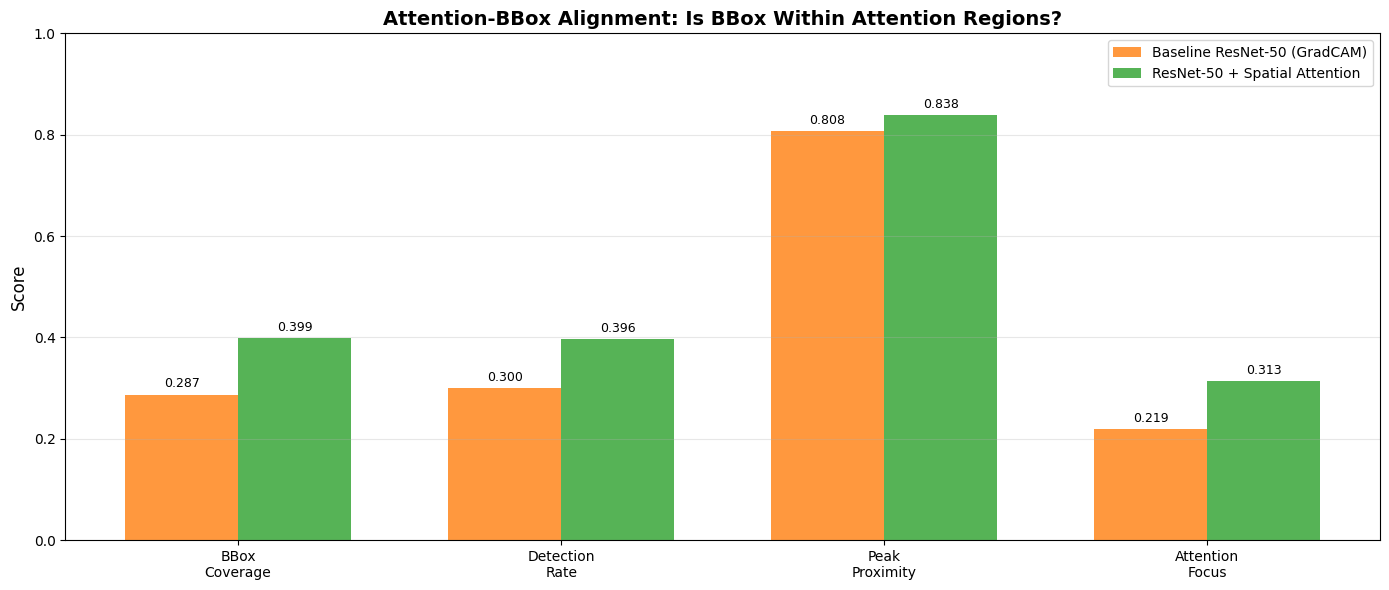

In [31]:
# ============================================================================
# USAGE EXAMPLE
# ============================================================================
import timm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load models
baseline_model = load_baseline_model('./best_resnet_nodule_model(NEW).pth', device)

base_model = timm.create_model('resnet50', pretrained=False, num_classes=2)
enhanced_model = load_enhanced_model(
    checkpoint_path='best_wsod_attention_resnet50.pth',
    base_model=base_model,
    device=device,
    freeze_backbone=True
)

# Run comparison
comparison_results = compare_models(
    baseline_model=baseline_model,
    enhanced_model=enhanced_model,
    test_dataset=test_dataset,
    device=device,
    model_names=['Baseline ResNet-50 (GradCAM)', 'ResNet-50 + Spatial Attention']
)